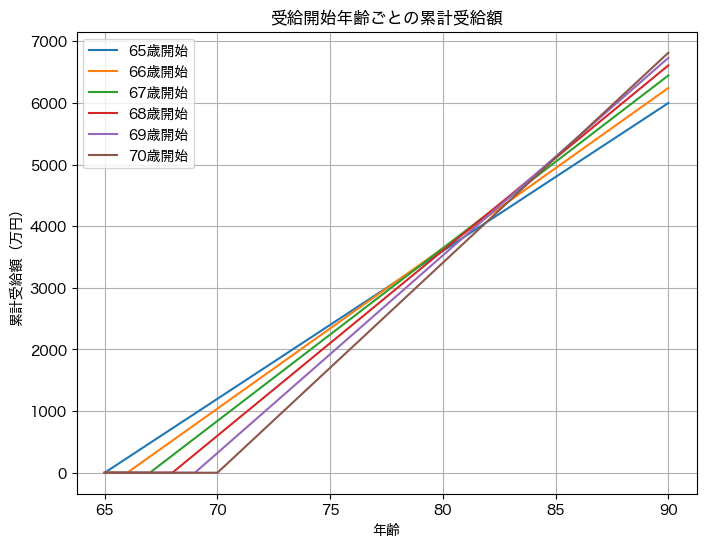

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 65歳での基準月額年金
base_pension = 200000  # 円/月

# 年齢の範囲
ages = np.linspace(65, 90, 500)

# 比較したい受給開始年齢
start_ages = [65, 66, 67, 68, 69, 70]

plt.figure(figsize=(8, 6))

for start_age in start_ages:
    # 繰下げ増額率（現行制度: 1か月あたり 0.7%）
    increase_rate = 0.007 * 12 * (start_age - 65)
    monthly_pension = base_pension * (1 + increase_rate)

    # 累計受給額
    total_received = np.where(
        ages < start_age,
        0,
        monthly_pension * 12 * (ages - start_age)
    )

    # 万円単位に変換
    total_received_man = total_received / 10000

    plt.plot(ages, total_received_man, label=f"{start_age}歳開始")

plt.xlabel("年齢")
plt.ylabel("累計受給額（万円）")
plt.title("受給開始年齢ごとの累計受給額")
plt.grid()
plt.legend()
plt.show()

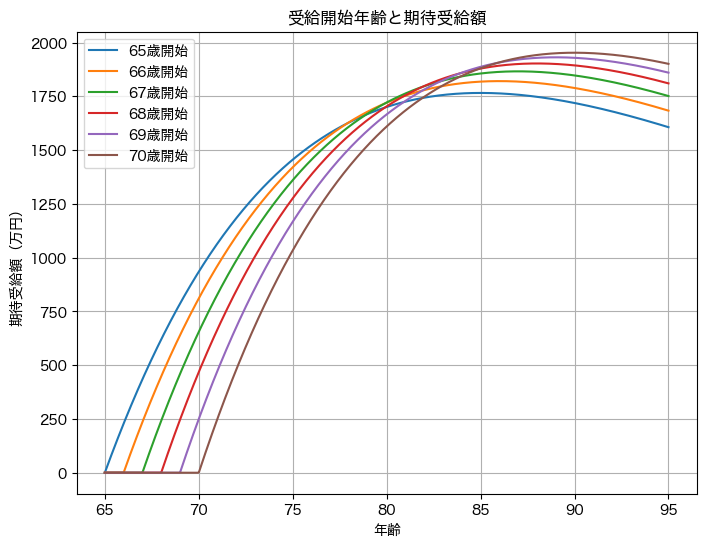

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 65歳時の月額年金
base_pension = 200000

# 年齢
ages = np.linspace(65, 95, 600)

# 受給開始年齢
start_ages = [65, 66, 67, 68, 69, 70]

# 簡易生存確率モデル
# 65歳から指数的に減ると仮定
def survival(age):
    return np.exp(-(age - 65)/20)

plt.figure(figsize=(8,6))

for start_age in start_ages:

    # 繰下げ増額
    increase = 0.007 * 12 * (start_age - 65)
    monthly = base_pension * (1 + increase)

    # 累計受給額
    total = np.where(
        ages < start_age,
        0,
        monthly * 12 * (ages - start_age)
    )

    # 生存確率
    S = survival(ages)

    # 期待受給額
    expected = total * S

    plt.plot(ages, expected/10000, label=f"{start_age}歳開始")

plt.xlabel("年齢")
plt.ylabel("期待受給額（万円）")
plt.title("受給開始年齢と期待受給額")

plt.grid()
plt.legend()

plt.show()